# Reinforcement Learning

## Taxi

from: https://www.gymlibrary.dev/environments/toy_text/taxi/

![taxi](https://www.gymlibrary.dev/_images/taxi.gif)


### Description

There are four designated locations in the grid world indicated by R(ed), G(reen), Y(ellow), and B(lue). When the episode starts, the taxi starts off at a random square and the passenger is at a random location. The taxi drives to the passenger’s location, picks up the passenger, drives to the passenger’s destination (another one of the four specified locations), and then drops off the passenger. Once the passenger is dropped off, the episode ends.


### Actions

There are 6 discrete deterministic actions:

    0: move south
    1: move north
    2: move east
    3: move west
    4: pickup passenger
    5: drop off passenger


### Observations

There are 500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations.

Note that there are 400 states that can actually be reached during an episode. The missing states correspond to situations in which the passenger is at the same location as their destination, as this typically signals the end of an episode. Four additional states can be observed right after a successful episodes, when both the passenger and the taxi are at the destination. This gives a total of 404 reachable discrete states.

Each state space is represented by the tuple: (taxi_row, taxi_col, passenger_location, destination)

An observation is an integer that encodes the corresponding state. The state tuple can then be decoded with the “decode” method.

Passenger locations:

    0: R(ed)
    1: G(reen)
    2: Y(ellow)
    3: B(lue)
    4: in taxi

Destinations:

    0: R(ed)
    1: G(reen)
    2: Y(ellow)
    3: B(lue)


### Rewards

    -1 per step unless other reward is triggered.
    +20 delivering passenger.
    -10 executing “pickup” and “drop-off” actions illegally.


### Install dependencies if needed
The following command will allow you to install gym, which is a toolkit for developing and comparing reinforcement learning algorithms: https://gym.openai.com/


pip install --upgrade git+https://github.com/openai/gym

### Import packages

In [1]:
import gym
from IPython.display import clear_output
from time import sleep
import numpy as np
from matplotlib import pyplot as pl

In [2]:
env = gym.make('Taxi-v3', render_mode='ansi').env

In [3]:
def print_frames(frames):
    for i, frame in enumerate(frames):
        clear_output(wait=True)
        print(frame['frame'])
        print(f'Timestep: {i + 1}')
        print(f"State: {frame['state']}")
        print(f"Action: {frame['action']}")
        print(f"Reward: {frame['reward']}")
        sleep(.1)

def argmax_choice(b):
    return np.random.choice(np.flatnonzero(b == b.max()))


# Brute force

First, let's test how much time it takes to an agent performing random actions to complete the task

In [9]:
env.reset()

epochs = 0
penalties, reward = 0, 0

frames = [] # for animation

done = False

while not done:
    action = env.action_space.sample()
    state, reward, done, _, _ = env.step(action)

    if reward == -10:
        penalties += 1
    
    # Put each rendered frame into dict for animation
    frames.append({
        'frame': env.render(),
        'state': state,
        'action': action,
        'reward': reward
        }
    )

    epochs += 1
    
print('Timesteps taken: {}'.format(epochs))
print('Penalties incurred: {}'.format(penalties))

        
print_frames(frames)


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Timestep: 1025
State: 475
Action: 5
Reward: 20


# Q-learning
Now, let's use reinforcemet learning to solve the task

In [4]:
actions_dict = {0:'south',
                1:'north',
                2:'east',
                3:'west',
                4:'pickup',
                5:'dropoff'}

In [5]:
q_table = np.zeros([env.observation_space.n, env.action_space.n])

q_table.shape

(500, 6)

## Visualizing the Q table before learning

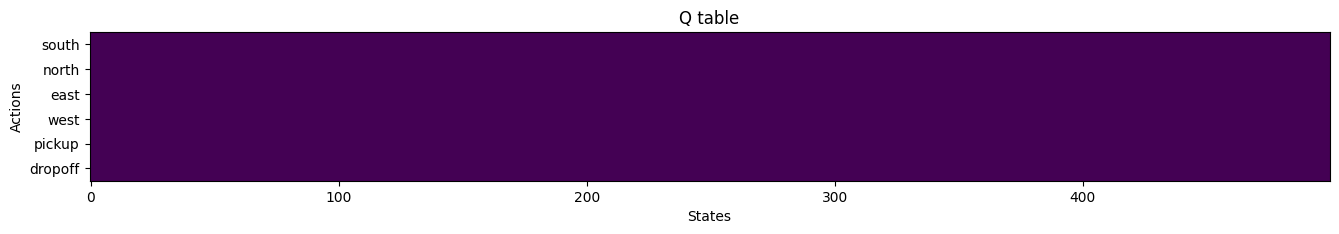

In [6]:
def show_q_table(table, binary=False):
    pl.figure(figsize=(16,4))
    
    if binary:
        temp = np.zeros(table.shape)
        for i,j in enumerate(np.argmax(table, axis=1)):
            temp[i,j] = 1
        pl.imshow(temp.T, interpolation='nearest', aspect=10)
    else:
        pl.imshow(table.T, interpolation='nearest', aspect=10)
    
    pl.yticks(range(len(actions_dict)), [actions_dict[k] for k in range(len(actions_dict))])
    pl.title('Q table')
    pl.xlabel('States')
    pl.ylabel('Actions')

show_q_table(q_table)

In [7]:
%%time

print('Training the agent')

# Hyperparameters
alpha = 0.1
gamma = 0.6
epsilon = 0.1

# For plotting metrics
all_epochs = []
all_penalties = []

for i in range(1, 20001):
    state, _ = env.reset()

    epochs, penalties, reward, = 0, 0, 0
    done = False
    
    while not done:
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()        # Explore action space
        else:
            action = argmax_choice(q_table[state,:])  # Exploit learned values

        next_state, reward, done, _, _ = env.step(action) 
        
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state,:])
        
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        if reward == -10:
            penalties += 1

        state = next_state
        epochs += 1
        
    if i % 100 == 0:
        clear_output(wait=True)
        print(f'Episode: {i}')

print('Training finished.\n')
print(f'Penalties: {penalties}')

Episode: 20000
Training finished.

Penalties: 0
CPU times: user 34.8 s, sys: 2.26 s, total: 37.1 s
Wall time: 33.9 s


## Visualizing the Q table after learning

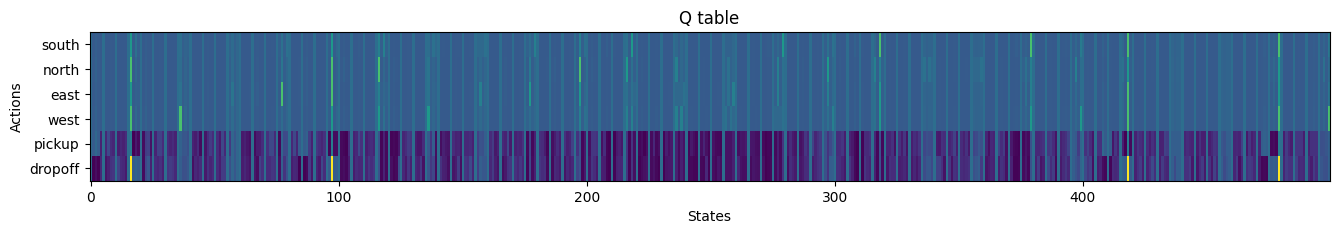

In [8]:
show_q_table(q_table)

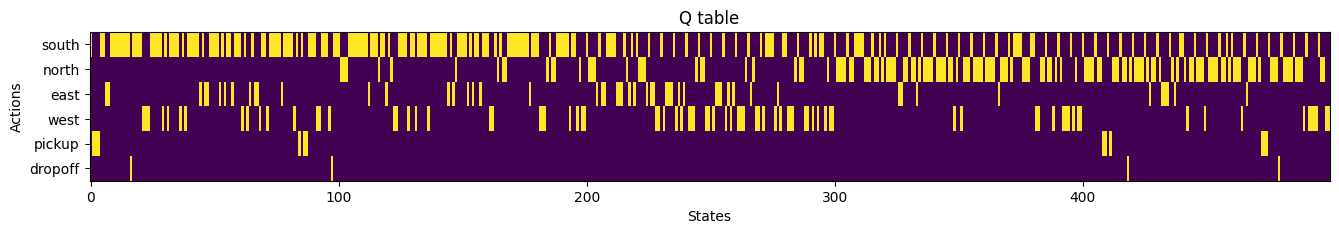

In [9]:
show_q_table(q_table, binary=True)

## Evaluate agent's performance after Q-learning

In [10]:
total_epochs, total_penalties, total_fails = 0, 0, 0
episodes = 100
max_epochs = 100

for _ in range(episodes):
    state, _ = env.reset()
    epochs, penalties, reward = 0, 0, 0
    
    done = False
    
    while not done and epochs < max_epochs:
        action = argmax_choice(q_table[state,:])
        state, reward, done, _, _ = env.step(action)

        if reward == -10:
            penalties += 1

        epochs += 1
    
    if epochs == max_epochs:
        total_fails += 1
    total_penalties += penalties
    total_epochs += epochs

print(f'Results after {episodes} episodes:')
print(f'Average timesteps per episode: {total_epochs / episodes}')
print(f'Average penalties per episode: {total_penalties / episodes}')
print(f'Number of fails: {total_fails}')

Results after 100 episodes:
Average timesteps per episode: 14.3
Average penalties per episode: 0.0
Number of fails: 2


## Visualizing an individual episode

In [11]:
state, _ = env.reset()
epochs, penalties, reward = 0, 0, 0

done = False

while not done:
    action = argmax_choice(q_table[state,:])
    state, reward, done, _, _ = env.step(action)

    if reward == -10:
        penalties += 1

    epochs += 1
    
    clear_output(wait=True)
    print(env.render())
    sleep(.2)

print(f'Timesteps: {epochs}')
print(f'Penalties: {penalties}')

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Timesteps: 16
Penalties: 0


## Analysis
Examine the behaviour of the agent for dropoff and pickup.

The following function decodes the state code [0, 500]

In [12]:
def decode_state(s):
    items = ['taxi row', 'taxi col', 'passenger location', 'destination']
    positions = ['R', 'G', 'Y', 'B', 'T']
    for i,j in enumerate(env.decode(s)):
        if i > 1:
            print(items[i], ':', positions[j])
        else:
            print(items[i], ':', j)

decode_state(120)

taxi row : 1
taxi col : 1
passenger location : R
destination : R


Knowing the code of each action

    0: move south
    1: move north
    2: move east
    3: move west
    4: pickup passenger
    5: drop off passenger

The states in which the agent decides to perform the action 'dropoff' can be computed as:

In [13]:
dropoff = np.where(np.argmax(q_table, axis=1) == 5)[0]

### Decode all the states in which the agent decides to perform the action 'dropoff' and analyse if the rules the agent learnt seem correct

### Decode all the states in which the agent decides to perform the action 'pickup' and analyse if the rules the agent learnt seem correct